In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

df = pd.read_csv("netflix_cleaned.csv")
df.head()

,show_id,title,type,director,cast,release_year,date_added,year_added,month_added,rating,rating_group,primary_genre,sub_genre,primary_country,secondary_country,duration_int,duration_type,movie_minutes,tv_seasons,description
0,s1,Dick Johnson Is Dead,movie,Kirsten Johnson,Unknown,2020,2021-09-25,2021,9,PG-13,Teen,Documentaries,NaN,United States,NaN,90.0,min,90.0,NaN,"As her father nears the end of his life, filmm..."
1,s2,Blood & Water,tv_show,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",2021,2021-09-24,2021,9,TV-MA,Adult,International TV Shows,TV Dramas,South Africa,NaN,2.0,Seasons,NaN,2.0,"After crossing paths at a party, a Cape Town t..."
2,s3,Ganglands,tv_show,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",2021,2021-09-24,2021,9,TV-MA,Adult,Crime TV Shows,International TV Shows,Unknown,NaN,1.0,Season,NaN,1.0,To protect his family from a powerful drug lor...
3,s4,Jailbirds New Orleans,tv_show,Unknown,Unknown,2021,2021-09-24,2021,9,TV-MA,Adult,Docuseries,Reality TV,Unknown,NaN,1.0,Season,NaN,1.0,"Feuds, flirtations and toilet talk go down amo..."
4,s5,Kota Factory,tv_show,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",2021,2021-09-24,2021,9,TV-MA,Adult,International TV Shows,Romantic TV Shows,India,NaN,2.0,Seasons,NaN,2.0,In a city of coaching centers known to train I...


In [3]:
df['content_length_category'] = None

# Movies
df.loc[df['type']=='movie','content_length_category'] = df['movie_minutes'].apply(
    lambda x: 'Short Movie' if x < 60 else ('Medium Movie' if x < 120 else 'Long Movie')
)

# TV Shows
df.loc[df['type']=='tv_show','content_length_category'] = df['tv_seasons'].apply(
    lambda x: 'Limited Series' if x == 1 else ('Multi Season' if x <= 3 else 'Long Running Series')
)

In [4]:
df['content_age'] = df['year_added'] - df['release_year']

In [5]:
def recency(age):
    if age <= 1:
        return 'New Release'
    elif age <= 5:
        return 'Recent'
    else:
        return 'Old Library'

df['content_recency'] = df['content_age'].apply(recency)

In [6]:
df['movie_minutes'] = pd.to_numeric(df['movie_minutes'], errors='coerce')
df['tv_seasons']   = pd.to_numeric(df['tv_seasons'], errors='coerce')
df['year_added']   = pd.to_numeric(df['year_added'], errors='coerce')
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

In [7]:
df[df['content_age'] < 0].shape

(14, 23)

In [8]:
df = df[df['content_age'] >= 0]

In [9]:
df['primary_genre'].isnull().sum()

np.int64(0)

### UNIVARIATE ANALYSIS

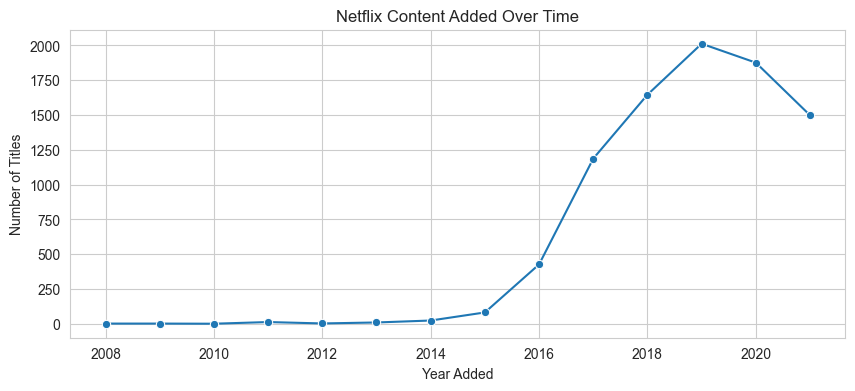

In [10]:
plt.figure(figsize=(10,4))
growth = df['year_added'].value_counts().sort_index()
sns.lineplot(x=growth.index, y=growth.values, marker='o')
plt.title("Netflix Content Added Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

rise in content additions after 2016 indicating global expansion

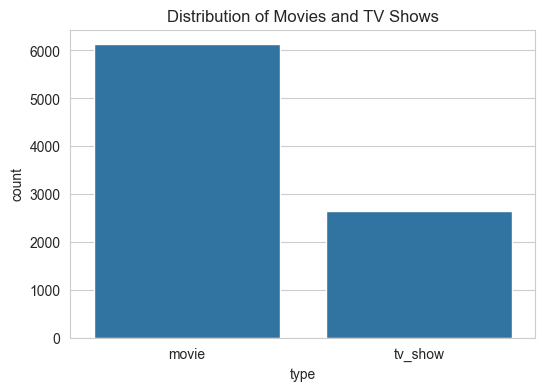

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Distribution of Movies and TV Shows")
plt.show()

catalog contains more movies than TV shows

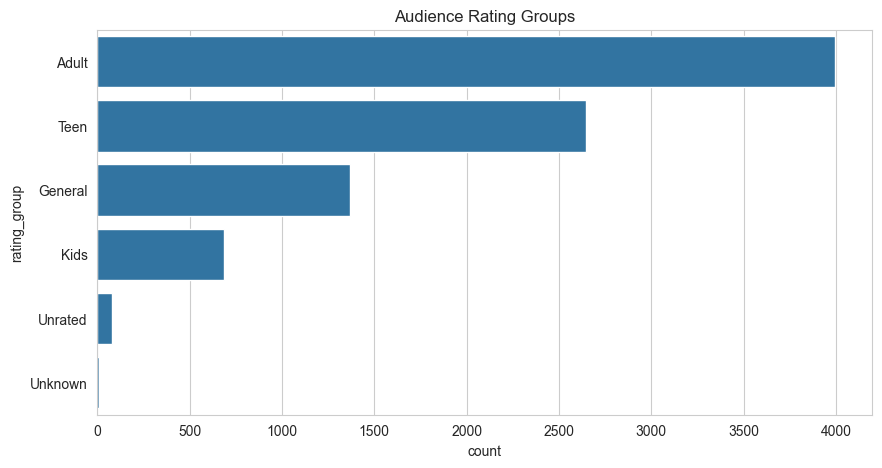

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='rating_group',order=df['rating_group'].value_counts().index)
plt.title("Audience Rating Groups")
plt.show()

majority of Netflix content targets Teen and Adult audiences

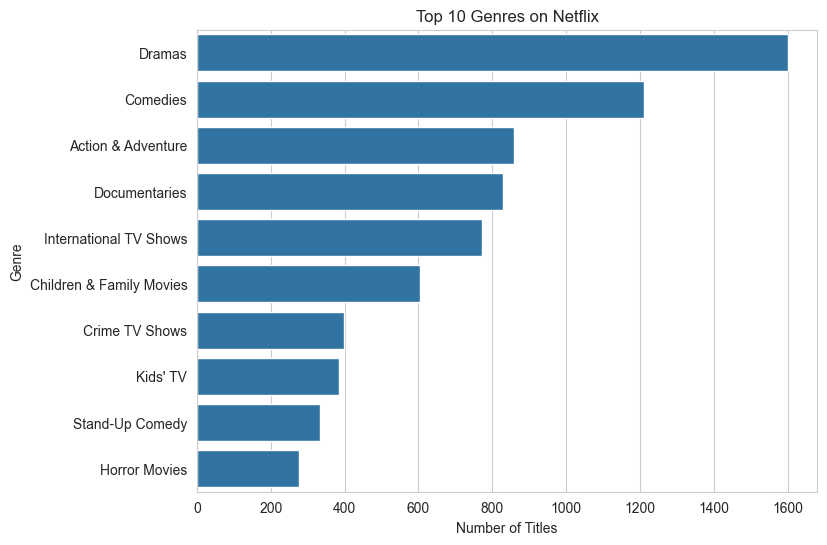

In [11]:
top_genres = df['primary_genre'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

Drama and International content dominate the platform, indicating Netflix emphasizes widely appealing storytelling formats to reach diverse audiences across countries.

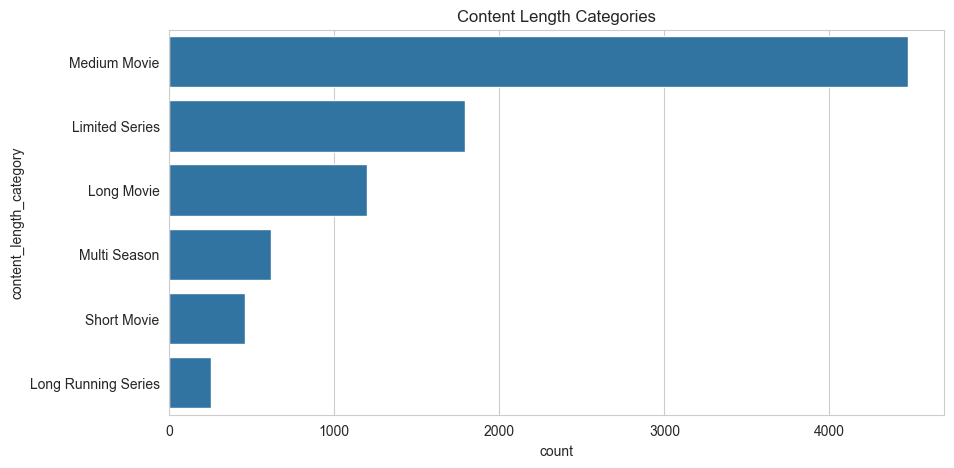

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='content_length_category',order=df['content_length_category'].value_counts().index)
plt.title("Content Length Categories")
plt.show()

##### Most movies fall in the medium-length range while TV shows are commonly multi-season.
 Netflix uses movies for quick consumption and series for sustained viewer retention.

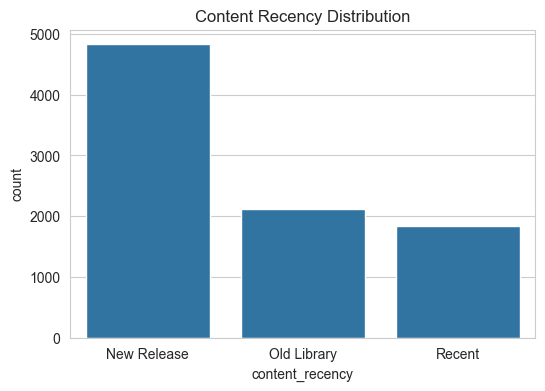

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='content_recency')
plt.title("Content Recency Distribution")
plt.show()

A significant portion of Netflix’s catalog consists of older titles, suggesting reliance on licensed content alongside newly produced releases.

### BIVARIATE ANALYSIS

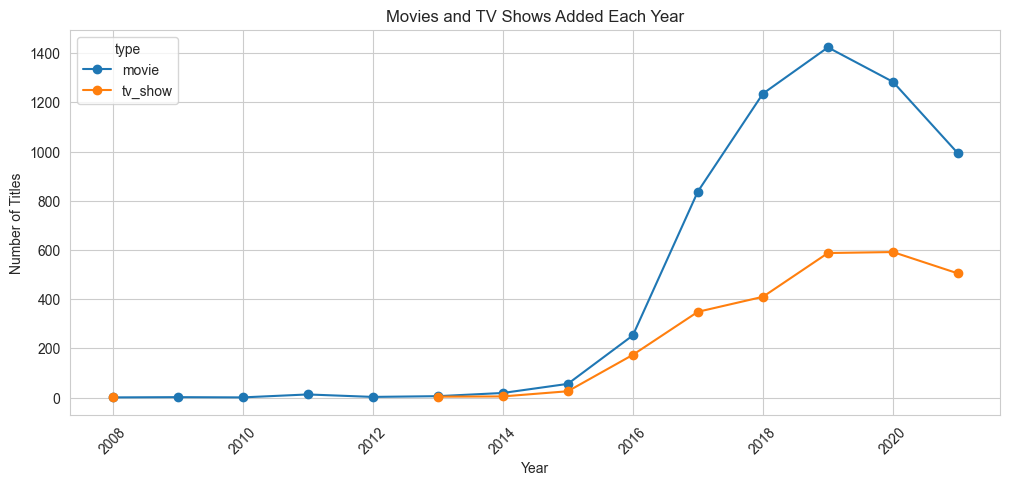

In [12]:
year_type = df.groupby(['year_added','type']).size().unstack()

year_type.plot(figsize=(12,5), marker='o')
plt.title("Movies and TV Shows Added Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In earlier years Netflix primarily added movies, but TV shows increased in later years, indicating a shift toward binge-watchable series to improve user retention.

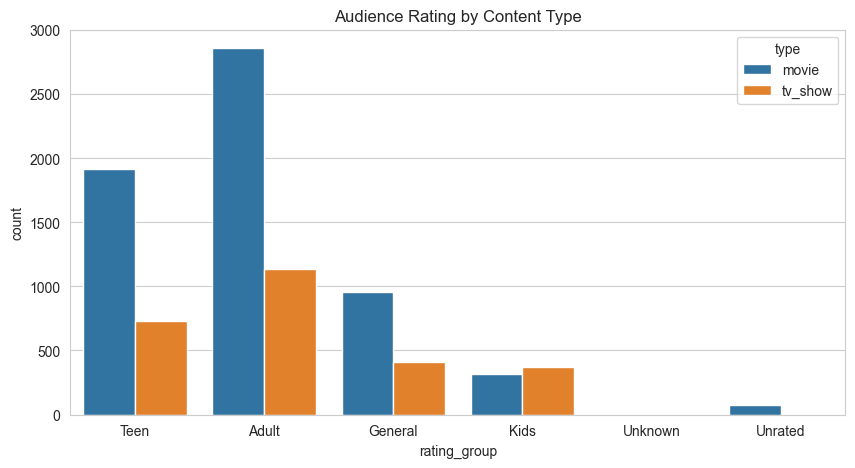

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='rating_group', hue='type')
plt.title("Audience Rating by Content Type")
plt.show()

Movies dominate the Adult and Teen categories, while TV shows appear more frequently in the Kids, 
Netflix uses series format for family and children engagement while films cater to mature audiences.

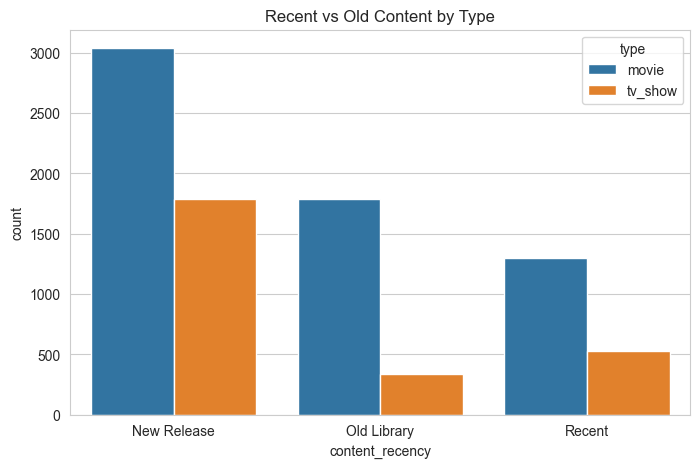

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='content_recency', hue='type')
plt.title("Recent vs Old Content by Type")
plt.show()

A large portion of the Netflix catalog consists of older library titles, especially movies.

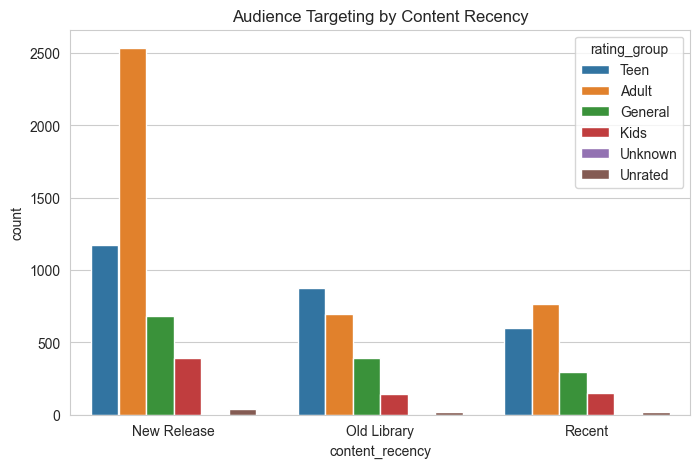

In [46]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='content_recency', hue='rating_group')
plt.title("Audience Targeting by Content Recency")
plt.show()

Most of the Recent Releases Target Mature Audiences

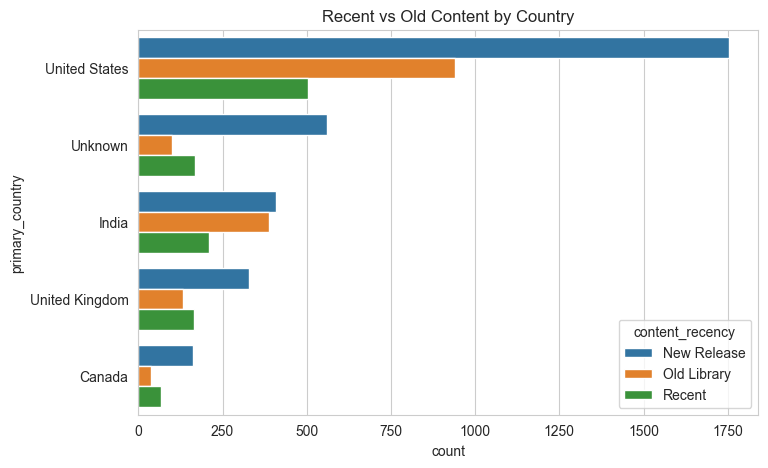

In [47]:
top5_country = df['primary_country'].value_counts().head(5).index
subset = df[df['primary_country'].isin(top5_country)]

plt.figure(figsize=(8,5))
sns.countplot(data=subset, y='primary_country', hue='content_recency')
plt.title("Recent vs Old Content by Country")
plt.show()

Among top 5 countries Netflix Catalog has More New Releases Excluding India where Old Library is added on par with new releases

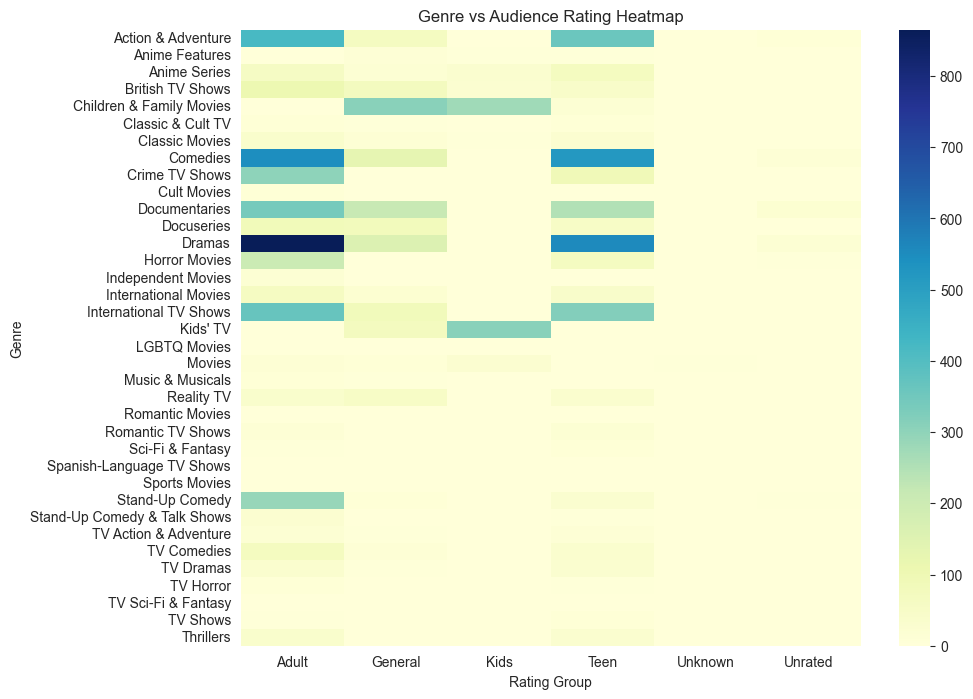

In [16]:
genre_rating = pd.crosstab(df['primary_genre'], df['rating_group'])

plt.figure(figsize=(10,8))
sns.heatmap(genre_rating, cmap='YlGnBu')
plt.title("Genre vs Audience Rating Heatmap")
plt.xlabel("Rating Group")
plt.ylabel("Genre")
plt.show()

Children and family genres align with kids ratings, while drama, crime, and thriller genres align with adult ratings

Are New Releases actually recent?

In [ ]:
new = df[df['content_recency']=='New Release']['release_year']
old = df[df['content_recency']=='Old Library']['release_year']

t_stat, p_value = stats.ttest_ind(new, old, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 57.745361496948235
P-value: 0.0


The t-test comparing release year of new releases and old library content produces a p-value less than 0.05. Therefore, the null hypothesis is rejected. New releases correspond to significantly newer production years, validating the recency classification and confirming Netflix differentiates between recently produced content and licensed library content.

In [17]:
df.to_csv("netflix_featured.csv", index=False)